# Recurrent Neural Networks
## The concept of "weight sharing"
Example of a fully connected network with three hidden layhers for a classification problem.

In [1]:
# Import dependencies
import torch
import torchvision
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import *
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
#from idlmam import *
from sklearn.metrics import accuracy_score

In [2]:
# Import the dl_utils.py file
import sys, os

# Add the project root to the python path
sys.path.insert(0, os.path.abspath("../DL_utils_EZA")) # Goes up one level from current folder

# Autoreload: picks up edits to dl_utils.py without restarting the kernel
%load_ext autoreload
%autoreload 2

# Import my own utilities
from dl_utils import * #import all my functions

print(" dl_utils loaded")

 dl_utils loaded


/home/efrain/Documents/Bio-AI-foundations/DL_utils_EZA/dl_utils.py:9: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [3]:
# Verification of CUDA present and force deterministic bahaviour for reproducibility with forced GPU usage

torch.backends.cudnn.benchmark = False  # better for RNNs with variable input sizes

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Device available: {device}')


Device available: cuda


In [4]:
# Load the MNIST data set
mnist_data_train = torchvision.datasets.MNIST("./data", train=True, download=False, transform=transforms.ToTensor())
mnist_data_test = torchvision.datasets.MNIST("./data", train=False, download=False, transform=transforms.ToTensor())

In [5]:
# Data Loader
mnist_train_loader = DataLoader(mnist_data_train, 
                                batch_size=128, 
                                shuffle=True, 
                                num_workers=6, 
                                pin_memory=True, 
                                persistent_workers=True,
                                drop_last=True
                                )
minst_test_loader = DataLoader(mnist_data_test, 
                               batch_size=2*128,
                               shuffle=False,
                               num_workers=6,
                               persistent_workers=True
                               )

# Hyperparameters
D = 28*28    # How many values are in the input. Used to determine of subsequent layers
n = 256      # Hidden layers size
C = 1        # Channels in the input
classes = 10 # number of classes

In [6]:
# Simple fully connected model
model_regular = nn.Sequential(
    Flatten(),
    nn.Linear(D, n),
    nn.Tanh(),
    nn.Linear(n, n),
    nn.Tanh(),
    nn.Linear(n, n),
    nn.Tanh(),
    nn.Linear(n, classes),
)

In [7]:
# Train the model
loss_func = nn.CrossEntropyLoss()
regular_results = train_simple_network_EZA(model_regular,
                                           loss_func,
                                           mnist_train_loader,
                                           test_loader=minst_test_loader,
                                           score_funcs={'Accuracy': accuracy_score},
                                           device=device,
                                           epochs=20
                                           )

Epoch: 100%|██████████| 20/20 [00:59<00:00,  2.96s/it]


In [8]:
# Model Shared weights
h_2 = nn.Linear(n, n)

model_shared = nn.Sequential(
    nn.Flatten(),
    nn.Linear(D, n),
    nn.Tanh(),
    h_2,
    nn.Tanh(),
    h_2,
    nn.Tanh(),
    nn.Linear(n, classes)
)

In [9]:
shared_results = train_simple_network_EZA(model_shared,
                                           loss_func,
                                           mnist_train_loader,
                                           test_loader=minst_test_loader,
                                           score_funcs={'Accuracy': accuracy_score},
                                           device=device,
                                           epochs=20
                                           )

Epoch: 100%|██████████| 20/20 [01:01<00:00,  3.05s/it]


<Axes: xlabel='epoch', ylabel='test Accuracy'>

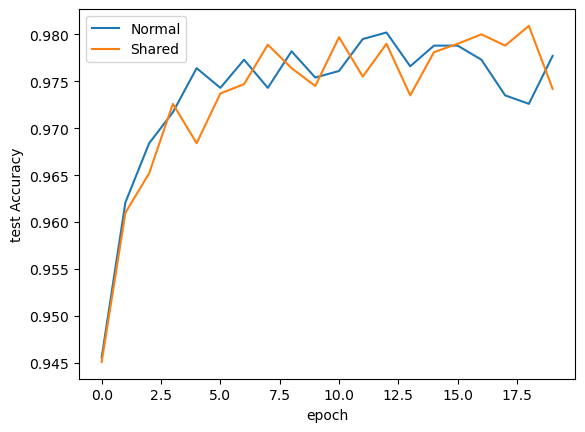

In [10]:
sns.lineplot(x='epoch', y='test Accuracy', data = regular_results, label='Normal')
sns.lineplot(x='epoch', y='test Accuracy', data = shared_results, label='Shared')

## RNNs in PyTorch
General workflow:
1. Create a `Dataset` to represent our data and load it
2. Create a `model` with PyTorch `nn.Module` class to take the dataset and create a prediction.
The RNNs needs the `Dataset` as vectors.
### A simple sequence classification problem

In [5]:
# Download and locate the data
zip_file_url = 'https://download.pytorch.org/tutorial/data.zip'
import requests, zipfile, io

r = requests.get(zip_file_url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall()

In [6]:
# Code to prepare the dataset
namge_language_data ={}
import unicodedata     # Remove UNICODE tokens to make life easier
import string

all_letters = string.ascii_letters + " .,;'"
n_letters = len(all_letters)
alphabet = {}
for i in range(n_letters):
    alphabet[all_letters[i]] = i

def unicodeToAscii(s):        # Turns Unicode string into plain ASCII
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in all_letters 
    )

for zip_path in z.namelist():               # Loops through every language, opens the zip file and reads the lines
    if "data/names/" in zip_path and zip_path.endswith(".txt"):
        lang = zip_path[len("data/names/"):-len(".txt")]
        with z.open(zip_path) as myfile:
            lang_names = [unicodeToAscii(line).lower() for line in str(myfile.read(), encoding='utf-8').strip().split("\n")]
            namge_language_data[lang] = lang_names
        print(lang, ": ", len(lang_names))  # prints out the name of each language

Arabic :  2000
Chinese :  268
Czech :  519
Dutch :  297
English :  3668
French :  277
German :  724
Greek :  203
Irish :  232
Italian :  709
Japanese :  991
Korean :  94
Polish :  139
Portuguese :  74
Russian :  9408
Scottish :  100
Spanish :  298
Vietnamese :  73


In [7]:
# Create a class for the dataset
class LanguageNameDataset(Dataset):
    """ 
    The data list contains each name and an associates index in the labels list indicates which language the name came from. 
    A vocabulary dictionary maps every unique item to an integer
    """
    def __init__(self, lang_name_dict, vocabulary):
        self.label_names = [x for x in lang_name_dict.keys()]
        self.data = []
        self.labels = []
        self.vocabulary = vocabulary
        for y, language in enumerate(self.label_names):
            for sample in lang_name_dict[language]:
                self.data.append(self.string2InputVec(sample))
                self.labels.append(y)

    def __len__(self):
        return len(self.data)
    def string2InputVec(self, input_string):
        """ 
        This method will convert any input string into a vector of long values,
        according to the vocabulary used by this object.
        input_string: the string to convert to a tensor
        """
        T = len(input_string)   # the characteres lenght of the string
        name_vec = torch.zeros((T), dtype=torch.long) # Creates a new tensor to store the result
        for pos, character in enumerate(input_string):   # Iterates through the string and places the appropriate values in tensor
            name_vec[pos] = self.vocabulary[character]
        return name_vec
    def __getitem__(self, index):
        return self.data[index], self.labels[index]


### The `collate_fn` with Padding
You cannot stack tensors of different sizes. PyTorch's default collate crashes trying to resize them into a uniform batch.

You need to tell the `DataLoader` how to handle variable-length sequences by providing a custom `collate_fn` that pads shorter sequences to match the longest one in the batch.

PyTorch has a built-in tool for exactly this: `torch.nn.utils.rnn.pad_sequence`.

In [8]:
from torch.nn.utils.rnn import pad_sequence

def pad_collate_fn(batch):
    """
    batch: list of (name_tensor, label) tuples from __getitem__
    Each name_tensor has a different length T.
    We pad all name tensors to the length of the longest one in the batch.
    """
    sequences, labels = zip(*batch)  # unzip into two separate tuples
    
    # pad_sequence stacks and pads: list of (T,) → (T_max, B)
    # batch_first=True reshapes to (B, T_max) which is what nn.RNN expects
    sequences_padded = pad_sequence(sequences, batch_first=True, padding_value=0)
    labels = torch.tensor(labels, dtype=torch.long)
    
    return sequences_padded, labels

In [9]:
# Create a new dataset to determine the language of a given name with 300 items in the split
dataset = LanguageNameDataset(namge_language_data, alphabet)
train_data, test_data = torch.utils.data.random_split(dataset, (len(dataset)-300, 300))
train_loader = DataLoader(train_data,
                          batch_size=32, 
                          shuffle=True, 
                          num_workers=4, 
                          pin_memory=True,   # Critical for eGPU
                          persistent_workers=True,
                          drop_last=False,
                          collate_fn=pad_collate_fn
)
test_loader = DataLoader(test_data,
                         batch_size=32,
                         shuffle=False,
                         num_workers=4,
                         pin_memory=True,   # Critical for eGPU
                         persistent_workers=True,
                         collate_fn=pad_collate_fn
)

### Embedding layers
Embedding represent items as vectors so that you can use other tools. We use the `nn.Embedding` layer

In [10]:
# Use of nn.Embedding to work with sequences of things. 
with torch.no_grad():
    input_sequence = torch.tensor([0,1,1,0,2], dtype=torch.long)
    embd = nn.Embedding(3,2)
    x_seq = embd(input_sequence)
    print(input_sequence.shape, x_seq.shape)
    print(x_seq)

torch.Size([5]) torch.Size([5, 2])
tensor([[ 1.2463, -0.1373],
        [-1.2935,  0.2609],
        [-1.2935,  0.2609],
        [ 1.2463, -0.1373],
        [-2.5409,  2.0248]])


### Making predictions using the last time step
Requires to extract the last time step 'hT' after it's processed by the RNN

In [11]:
# LastTimeStep hT function
class LastTimeStep(nn.Module):
    """ 
    A class for extracting the hiden activations of the last time 
    step following the output of a Pytorch RNN module.
    """
    def __init__(self, rnn_layers=1, bidirectional=False):
        super(LastTimeStep, self).__init__()
        self.rnn_layers = rnn_layers
        if bidirectional:
            self.num_directions = 2
        else:
            self.num_directions = 1

    def forward(self, input):
        rnn_output = input[0]   # REsults in either a tuple (out, ht) or a tubpel (out, (ht,ct))
        last_step = input[1]   # This is the ht unless it's a tuple
        if(type(last_step) == tuple):
            last_step = last_step[0]

        batch_size = last_step.shape[1]  # Per the docs, shape is (num_layers*num_directions, batch, hiden_size)
        last_step = last_step.view(self.rnn_layers, self.num_directions, batch_size, -1) # Reshapes so everything is separated
        last_step = last_step[self.rnn_layers-1] # We want the last layer's result
        last_step = last_step.permute(1,0,2) # Reorders so the batch comes first
        last_step = last_step.reshape(batch_size, -1)  # flattens the last two dimensions into one
        return last_step

### The RNN model

In [17]:
# Variables
D = 64      # Size of the nn.Embedding result
vocab_size = (len(all_letters))  # number of letters
hidden_nodes = 256   # number of neurons in the RNNM
classes = len(dataset.label_names)  # number of classes or number of languages
loss_function = nn.CrossEntropyLoss()

# RNN model
first_rnn = nn.Sequential(
    nn.Embedding(vocab_size, D),   # (B, T) -> (B,T,D)
    nn.RNN(D, hidden_nodes, batch_first=True),  #  (B,T,D) -> ((B,T,D), (S,B,D))
    LastTimeStep(),  # The tanh activation is built into the RNN. We take RNN ouptut and reduce to (B,D)
    nn.Linear(hidden_nodes, classes)
)

In [20]:
# Train our first RNN
batch_one_train = train_simple_network_EZA(first_rnn,
                                           loss_function,
                                           train_loader,
                                           test_loader=test_loader,
                                           score_funcs={'Accuracy': accuracy_score},
                                           device=device,
                                           epochs=100,
                                           use_amp=True  # Allows to work with bigger batch sizes!!
)

Epoch: 100%|██████████| 100/100 [02:57<00:00,  1.78s/it]


<Axes: xlabel='epoch', ylabel='test Accuracy'>

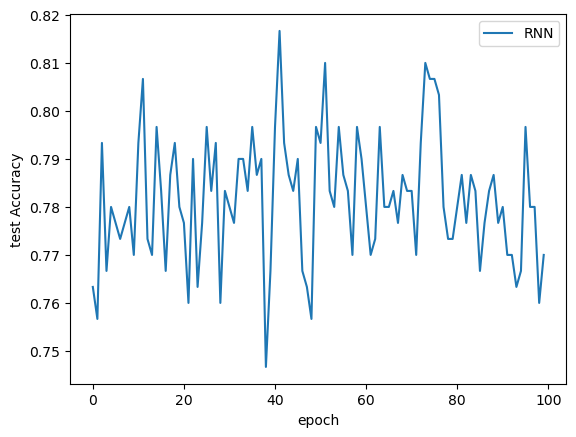

In [33]:
# Plot results
sns.lineplot(x='epoch', y='test Accuracy', data=batch_one_train, label='RNN')

In [52]:
# Test the trained model

pred_rnn = first_rnn.to('cpu').eval()
with torch.no_grad():
    preds = F.softmax(pred_rnn(
        dataset.string2InputVec('tom').reshape(1,-1)), dim=1)
    for class_id in range(len(dataset.label_names)):
        print(dataset.label_names[class_id], ":", preds[0, class_id].item()*100, "%")

Arabic : 1.8906442448496819 %
Chinese : 0.8259426802396774 %
Czech : 7.333522289991379 %
Dutch : 0.07454031147062778 %
English : 52.928149700164795 %
French : 0.1795698655769229 %
German : 0.411414448171854 %
Greek : 0.5946650635451078 %
Irish : 3.8480352610349655 %
Italian : 5.501316115260124 %
Japanese : 15.53308516740799 %
Korean : 2.060265652835369 %
Polish : 0.09766373550519347 %
Portuguese : 0.7055703084915876 %
Russian : 5.072716251015663 %
Scottish : 0.7648805622011423 %
Spanish : 0.8228755556046963 %
Vietnamese : 1.3551429845392704 %


## More Complex RNNs
### Multiple RNN layers

In [14]:
# RNN model with 3 layers
rnn_3layer = nn.Sequential(
    nn.Embedding(vocab_size, D),   # (B, T) --> (B,T,D)
    nn.RNN(D, hidden_nodes, num_layers=3, batch_first=True), #(B,T,D) --> ((B,T,D), (S,B,D))
    LastTimeStep(rnn_layers=3),  # Takes the RNN ouptut and reduces it to one item (B,D)
    nn.Linear(hidden_nodes, classes)

)

In [23]:
rnn_3layer.to(device)
rnn_3layer_results = train_simple_network_EZA(rnn_3layer,
                                              loss_function,
                                              train_loader,
                                              test_loader=test_loader,
                                              score_funcs={'Accuracy': accuracy_score},
                                              device=device,
                                              epochs=100,
                                              use_amp=True
)

Epoch: 100%|██████████| 100/100 [03:23<00:00,  2.03s/it]


<Axes: xlabel='epoch', ylabel='test Accuracy'>

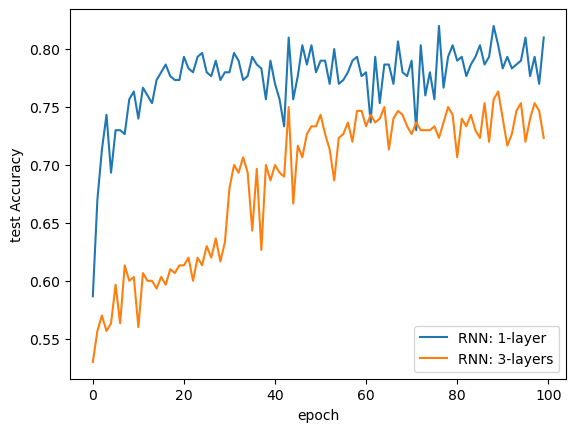

In [22]:
# Plot results
sns.lineplot(x='epoch', y='test Accuracy', data=batch_one_train, label='RNN: 1-layer')
sns.lineplot(x='epoch', y='test Accuracy', data=rnn_3layer_results, label='RNN: 3-layers')

### Bidirectional RNNs

In [24]:
# Bidirectional RNN model
rnn_3layer_bidir = nn.Sequential(
    nn.Embedding(vocab_size, D),
    nn.RNN(D, hidden_nodes, num_layers=3, batch_first=True, bidirectional=True),
    LastTimeStep(rnn_layers=3, bidirectional=True),
    nn.Linear(hidden_nodes*2, classes)
)

In [25]:
rnn_3layer_bidir_results = train_simple_network_EZA(rnn_3layer_bidir,
                                                    loss_function,
                                                    train_loader,
                                                    test_loader=test_loader,
                                                    score_funcs={'Accuracy': accuracy_score},
                                                    device=device,
                                                    epochs=100,
                                                    use_amp=True
)

Epoch: 100%|██████████| 100/100 [04:12<00:00,  2.52s/it]


(-1.0, 20.0)

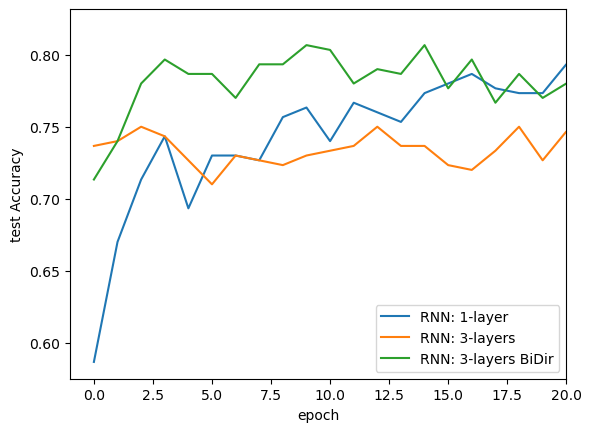

In [30]:
sns.lineplot(x='epoch', y='test Accuracy', data=batch_one_train, label='RNN: 1-layer')
sns.lineplot(x='epoch', y='test Accuracy', data=rnn_3layer_results, label='RNN: 3-layers')
sns.lineplot(x='epoch', y='test Accuracy', data=rnn_3layer_bidir_results, label='RNN: 3-layers BiDir')
plt.xlim(-1, 20)